In [1]:
# Chakraborti et al. 2013
from equipartition import Equipartition
import numpy as np
import scipy
import astropy
import scipy
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt

In [2]:
import scipy.stats

def confidence_interval(data, confidence=0.50):
    mu = np.mean(data)

    functomin = lambda x : np.abs(len(data[((mu - x) < data) & (data < (mu + x))])/len(data) - confidence)
    res = scipy.optimize.minimize(functomin, mu/10, method = "Nelder-Mead", bounds = [(0, np.inf)])
    return mu, mu - res.x[0], mu + res.x[0]

In [3]:
N = 1000
# a_trunc = 0
# b_trunc = np.inf
# a, b = (a_trunc - loc) / scale, (b_trunc - loc) / scale

# SN 2011ja
Fmjy = scipy.stats.truncnorm.rvs(-0.829/0.033, np.inf, 0.829, 0.033, N)
nup10 = scipy.stats.truncnorm.rvs(-9.29/0.39, np.inf, 9.29/10, 0.39/10, N)
tdays = scipy.stats.truncnorm.rvs(-7/1, np.inf, 7, 1, N)
smallDist = scipy.stats.truncnorm.rvs(-1.0368e+25/2.7771e+23, np.inf, 1.0368e+25, 2.7771e+23, N)
p = 3
epse = 0.1
epsB = 0.1

eq = Equipartition(Fmjy, nup10, tdays, 0, 0, p = p, smallDist = smallDist, newtonian = True, corr = True,\
              hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True,\
              epse = epse, epsB = epsB, fA = 1, fV = 0.36, fOmega = 4)

In [4]:
print("SN 2011ja equipartition analysis with corrections")
print("newtonian equipartition E = {:.3e}±{:.3e}".format(np.mean(eq.energyeq()), np.std(eq.energyeq())))
print("newtonian equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("newtonian equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
print("newtonian equipartition n = {:.3e}±{:.3e}".format(np.mean(eq.CNMnumDens()), np.std(eq.CNMnumDens())))
print("newtonian equipartition Ne= {:.3e}±{:.3e}".format(np.mean(eq.Ne()), np.std(eq.Ne())))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("newtonian equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))

SN 2011ja equipartition analysis with corrections
newtonian equipartition E = 1.778e+44±1.645e+43
newtonian equipartition R = 4.762e+14±2.507e+13
newtonian equipartition B = 1.914e+00±8.077e-02
newtonian equipartition n = 2.358e+04±1.991e+03
newtonian equipartition Ne= 1.063e+49±9.836e+47
newtonian          betaeqN= 2.691e-02±4.393e-03
newtonian equipartition gM= 2.000e+00±0.000e+00


In [5]:
# Bright et al. 2025 EP240414a
COSMO = FlatLambdaCDM(
    H0=70,      # km/s/Mpc
    Om0=0.3,    # matter density parameter
    Tcmb0=2.725 # CMB temperature in K
)
Fmjy = scipy.stats.truncnorm.rvs(-0.434/0.021, np.inf, 0.434, 0.021, N); Fmjy_scalar = 0.434
nup10 = 3/10
tdays = 30
z = scipy.stats.truncnorm.rvs(-0.4018/0.0010, np.inf, 0.4018, 0.0010, N); z_scalar = 0.4018
p = scipy.stats.truncnorm.rvs((2-2.16)/0.3, (3-2.16)/0.3, 2.16, 0.3, N); p_scalar = 2.16
epse = 0.1 # 0.1
epsB = 0.001 # 0.3

eq = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = True, BDfactor = True,\
              hotprotons = False, numelectrons = False, outofequipartition = False, energysum = True,\
              epse = epse, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO) # fV usually should be 1 and fOmega usually should be 4 for the Newtonian case

In [6]:
print("EP240414a equipartition analysis Newtonian without corrections (weird geometry + unphysical)") # BDfactor = True reproduces Bright et al.
print("newtonian equipartition E = {:.3e}±{:.3e}".format(np.mean(eq.energyeq()), np.std(eq.energyeq())))
print("newtonian equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("newtonian equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
print("newtonian equipartition n = {:.3e}±{:.3e}".format(np.mean(eq.CNMnumDens()), np.std(eq.CNMnumDens())))
print("newtonian equipartition Ne= {:.3e}±{:.3e}".format(np.mean(eq.Ne()), np.std(eq.Ne())))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("newtonian equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))
print("          equipartition ge= {:.3e}±{:.3e}".format(np.mean(eq.gammae()), np.std(eq.gammae())))

EP240414a equipartition analysis Newtonian without corrections (weird geometry + unphysical)
newtonian equipartition E = 1.465e+49±8.758e+47
newtonian equipartition R = 1.775e+17±4.259e+15
newtonian equipartition B = 8.599e-02±5.208e-04
newtonian equipartition n = 1.488e+01±2.251e-01
newtonian equipartition Ne= 8.713e+52±4.949e+51
newtonian          betaeqN= 3.201e+00±7.683e-02
newtonian equipartition gM= 1.156e+02±6.093e+01
          equipartition ge= 1.311e+02±3.943e-01


C:\Users\rohdo\OneDrive\Desktop\Python\equipartition\equipartition\equipartition.py:186: UserWarning: estimated gammae (at peak) is smaller than estimated gammaM for nu_a > nu_m. Setting kappa = 1 in this case
  warnings.warn("estimated gammae (at peak) is smaller than estimated gammaM for nu_a > nu_m. Setting kappa = 1 in this case")


In [7]:
eq = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = False, onAxis = True,\
              hotprotons = False, numelectrons = False, outofequipartition = False, energysum = True,\
              epse = epse, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO)

In [8]:
print("EP240414a equipartition analysis relativistic without corrections")
E = eq.energyeq()
print("          equipartition E = {:.3e}±{:.3e}".format(np.mean(E), np.std(E)))
_, lb, ub = confidence_interval(E)
print("confidence interval         [{:.3e}, {:.3e}]".format(lb, ub))
print("confidence                ", len(E[(lb < E) & (E < ub)])/len(E))
print("          equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("          equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
numDens = eq.CNMnumDens()
print("          equipartition n = {:.3e}±{:.3e}".format(np.mean(numDens), np.std(numDens)))
_, lb, ub = confidence_interval(numDens, confidence=0.5)
print("confidence interval         [{:.3e}, {:.3e}]".format(lb, ub))
print("confidence                ", len(numDens[(lb < numDens) & (numDens < ub)])/len(numDens))
Ne = eq.Ne()
print("          equipartition Ne= {:.3e}±{:.3e}".format(np.mean(Ne), np.std(Ne)))
_, lb, ub = confidence_interval(Ne, confidence = 0.5)
print("confidence interval         [{:.3e}, {:.3e}]".format(lb, ub))
print("confidence                ", len(Ne[(lb < Ne) & (Ne < ub)])/len(Ne))
print("                 gammaBulk= {:.3e}±{:.3e}".format(np.mean(eq.gammaBulk()), np.std(eq.gammaBulk())))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("          equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))
print("          equipartition ge= {:.3e}±{:.3e}".format(np.mean(eq.gammae()), np.std(eq.gammae())))
print("                     curlc= {:.3e}±{:.3e}".format(np.mean(eq.C()), np.std(eq.C())))

EP240414a equipartition analysis relativistic without corrections
          equipartition E = 1.821e+48±7.640e+46
confidence interval         [1.771e+48, 1.870e+48]
confidence                 0.499
          equipartition R = 2.025e+17±1.277e+16
          equipartition B = 4.030e-02±2.261e-03
          equipartition n = 2.369e+00±3.443e-01
confidence interval         [2.118e+00, 2.621e+00]
confidence                 0.5
          equipartition Ne= 7.786e+51±2.483e+50
confidence interval         [7.008e+51, 8.565e+51]
confidence                 0.999
                 gammaBulk= 1.614e+00±3.502e-02
newtonian          betaeqN= 3.497e+00±1.838e-01
          equipartition gM= 2.527e+01±1.425e+01
          equipartition ge= 1.130e+02±1.733e+00
                     curlc= 3.733e+00±4.232e-01


In [9]:
eq = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = False, onAxis = True,\
              hotprotons = True, numelectrons = True, outofequipartition = False, energysum = True,\
              epse = epse, epsB = None, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO)

In [10]:
print("EP240414a equipartition analysis relativistic with corrections but still in equipartition")
E = eq.energyeq()
print("          equipartition E = {:.3e}±{:.3e}".format(np.mean(E), np.std(E)))
_, lb, ub = confidence_interval(E)
print("confidence interval         [{:.3e}, {:.3e}]".format(lb, ub))
print("confidence                ", len(E[(lb < E) & (E < ub)])/len(E))
print("          equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("          equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
numDens = eq.CNMnumDens()
print("          equipartition n = {:.3e}±{:.3e}".format(np.mean(numDens), np.std(numDens)))
_, lb, ub = confidence_interval(numDens, confidence=0.75)
print("confidence interval         [{:.3e}, {:.3e}]".format(lb, ub))
print("confidence                ", len(numDens[(lb < numDens) & (numDens < ub)])/len(numDens))
Ne = eq.Ne()
print("          equipartition Ne= {:.3e}±{:.3e}".format(np.mean(Ne), np.std(Ne)))
_, lb, ub = confidence_interval(Ne, confidence = 0.75)
print("confidence interval         [{:.3e}, {:.3e}]".format(lb, ub))
print("confidence                ", len(Ne[(lb < Ne) & (Ne < ub)])/len(Ne))
print("                 gammaBulk= {:.3e}±{:.3e}".format(np.mean(eq.gammaBulk()), np.std(eq.gammaBulk())))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("          equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))
print("          equipartition ge= {:.3e}±{:.3e}".format(np.mean(eq.gammae()), np.std(eq.gammae())))
print("                       nuc= {:.3e}±{:.3e}".format(np.mean(eq.nuc()), np.std(eq.nuc())))

EP240414a equipartition analysis relativistic with corrections but still in equipartition
          equipartition E = 6.307e+48±3.455e+47
confidence interval         [6.091e+48, 6.523e+48]
confidence                 0.5
          equipartition R = 2.368e+17±1.640e+16
          equipartition B = 6.459e-02±2.668e-03
          equipartition n = 7.048e+00±1.048e+01
confidence interval         [6.344e+00, 7.753e+00]
confidence                 0.049
          equipartition Ne= 2.922e+52±3.776e+52
confidence interval         [9.005e+51, 4.944e+52]
confidence                 0.75
                 gammaBulk= 1.706e+00±4.274e-02
newtonian          betaeqN= 3.996e+00±2.355e-01
          equipartition gM= 2.911e+01±1.649e+01
          equipartition ge= 8.615e+01±7.303e-01
                       nuc= 1.390e+15±1.630e+14


In [11]:
print("EP240414a equipartition analysis relativistic with corrections but still in equipartition logs")
print("          equipartition E = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.energyeq())), np.std(np.log10(eq.energyeq()))))
print("          equipartition R = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.Req())), np.std(np.log10(eq.Req()))))
print("          equipartition B = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.magField())), np.std(np.log10(eq.magField()))))
print("          equipartition n = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.CNMnumDens())), np.std(np.log10(eq.CNMnumDens()))))
print("          equipartition Ne= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.Ne())), np.std(np.log10(eq.Ne()))))
print("                 gammaBulk= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.gammaBulk())), np.std(np.log10(eq.gammaBulk()))))
print("newtonian          betaeqN= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.betaeqN())), np.std(np.log10(eq.betaeqN()))))
print("          equipartition gM= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.gammaM())), np.std(np.log10(eq.gammaM()))))
print("          equipartition ge= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.gammae())), np.std(np.log10(eq.gammae()))))
print("                       nuc= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.nuc())), np.std(np.log10(eq.nuc()))))

EP240414a equipartition analysis relativistic with corrections but still in equipartition logs
          equipartition E = 48.80±0.02
          equipartition R = 17.37±0.03
          equipartition B = -1.19±0.02
          equipartition n = 0.61±0.40
          equipartition Ne= 52.29±0.34
                 gammaBulk= 0.23±0.01
newtonian          betaeqN= 0.60±0.03
          equipartition gM= 1.36±0.35
          equipartition ge= 1.94±0.00
                       nuc= 15.14±0.05


In [12]:
eq = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = False, onAxis = True, corr = True,\
              hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True,\
              epse = epse, epsB = epsB, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO)

In [13]:
print("EP240414a equipartition analysis relativistic with corrections and out of equipartition") # technically out of equipartition
print("          equipartition E = {:.3e}±{:.3e}".format(np.mean(eq.energyeq()), np.std(eq.energyeq())))
print("          equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("          equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
print("          equipartition n = {:.3e}±{:.3e}".format(np.mean(eq.CNMnumDens()), np.std(eq.CNMnumDens())))
print("          equipartition Ne= {:.3e}±{:.3e}".format(np.mean(eq.Ne()), np.std(eq.Ne())))
print("                  gammBulk= {:.3e}±{:.3e}".format(np.mean(eq.gammaBulk()), np.std(eq.gammaBulk())))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("          equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))
print("          equipartition ge= {:.3e}±{:.3e}".format(np.mean(eq.gammae()), np.std(eq.gammae())))
print("                       nuc= {:.3e}±{:.3e}".format(np.mean(eq.nuc()), np.std(eq.nuc())))

EP240414a equipartition analysis relativistic with corrections and out of equipartition
          equipartition E = 8.582e+49±1.453e+49
          equipartition R = 1.600e+17±1.227e+16
          equipartition B = 1.927e-02±3.672e-04
          equipartition n = 3.290e+02±3.843e+02
          equipartition Ne= 5.506e+53±5.309e+53
                  gammBulk= 1.493e+00±3.609e-02
newtonian          betaeqN= 2.872e+00±1.941e-01
          equipartition gM= 2.048e+01±1.179e+01
          equipartition ge= 1.718e+02±2.774e+00
                       nuc= 5.718e+16±3.131e+15


In [14]:
print("EP240414a equipartition analysis relativistic with corrections and out of equipartition logs")
print("          equipartition E = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.energyeq())), np.std(np.log10(eq.energyeq()))))
print("          equipartition R = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.Req())), np.std(np.log10(eq.Req()))))
print("          equipartition B = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.magField())), np.std(np.log10(eq.magField()))))
print("          equipartition n = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.CNMnumDens())), np.std(np.log10(eq.CNMnumDens()))))
print("          equipartition Ne= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.Ne())), np.std(np.log10(eq.Ne()))))
print("                 gammaBulk= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.gammaBulk())), np.std(np.log10(eq.gammaBulk()))))
print("newtonian          betaeqN= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.betaeqN())), np.std(np.log10(eq.betaeqN()))))
print("          equipartition gM= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.gammaM())), np.std(np.log10(eq.gammaM()))))
print("          equipartition ge= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.gammae())), np.std(np.log10(eq.gammae()))))
print("                       nuc= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.nuc())), np.std(np.log10(eq.nuc()))))

EP240414a equipartition analysis relativistic with corrections and out of equipartition logs
          equipartition E = 49.93±0.07
          equipartition R = 17.20±0.03
          equipartition B = -1.72±0.01
          equipartition n = 2.34±0.35
          equipartition Ne= 53.63±0.28
                 gammaBulk= 0.17±0.01
newtonian          betaeqN= 0.46±0.03
          equipartition gM= 1.21±0.34
          equipartition ge= 2.24±0.01
                       nuc= 16.76±0.02


In [15]:
tsec = tdays * 86400
st = 6.652e-25 # thomson cross section cgs
gammac = lambda B, G : 6 * np.pi * 9.109e-28 * 2.998e10 / (st * B**2 * G * tsec/(1 + z_scalar))
nuc = lambda B, G, D: D * gammac(B, G)**2 * 4.80320425e-10 * B / (2 * np.pi * 9.109e-28 * 2.998e10 * (1 + z_scalar))

nuc_actual = 1e16 #9e9 requires too large of a nuc than what Bright et al. constrains

func = lambda eB: Equipartition(Fmjy_scalar, nup10, tdays, z_scalar, 0, p = p_scalar, newtonian = False, onAxis = True, corr = True,\
              hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True,\
              epse = epse, epsB = eB, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO)

constraint = lambda eB : nuc(func(eB).magField(), func(eB).gammaBulk(), func(eB).deltaD()) - nuc_actual

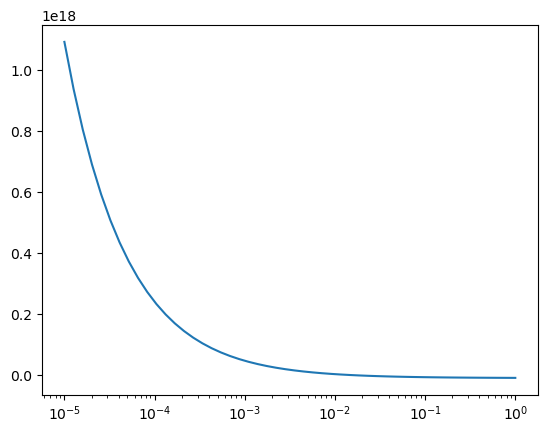

In [16]:
eB = np.geomspace(0.00001, 0.999)
plt.xscale("log")
plt.plot(eB, constraint(eB))

In [17]:
scipy.optimize.brentq(constraint, 1e-12, 1 - 1e-12)

0.01486405266335272

In [18]:
N = 10

Fmjy = scipy.stats.truncnorm.rvs(-0.434/0.021, np.inf, 0.434, 0.021, N); Fmjy_scalar = 0.434
nup10 = 3/10
tdays = 30
z = scipy.stats.truncnorm.rvs(-0.4018/0.0010, np.inf, 0.4018, 0.0010, N); z_scalar = 0.4018
p = scipy.stats.truncnorm.rvs((2-2.16)/0.3, (3-2.16)/0.3, 2.16, 0.3, N); p_scalar = 2.16
epse = 0.1 # 0.1
epsB = 0.001 # 0.3

eBs = np.geomspace(0.0001, 0.999)

eqs = [Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = False, onAxis = True, corr = True,\
              hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True,\
              epse = epse, epsB = eB, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO) for eB in eBs]

In [19]:
epsBineqs = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = False, onAxis = True, corr = True,\
              hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True,\
              epse = epse, epsB = None, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO).epsB
epsBineqmean = np.mean(epsBineqs)
epsBineqstd = np.std(epsBineqs, ddof = 1)

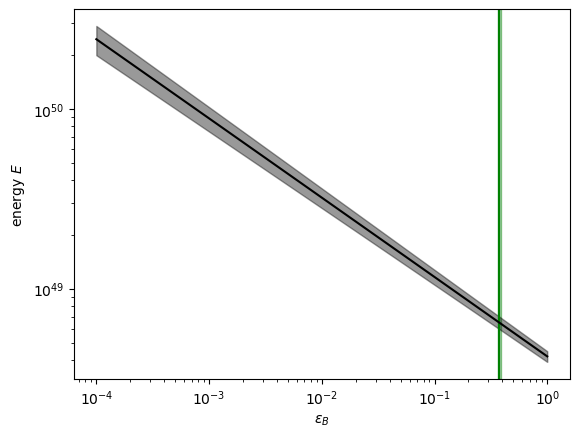

In [20]:
energyeqmean = np.array([np.mean(eq.energyeq()) for eq in eqs])
energyeqstd = np.array([np.std(eq.energyeq(), ddof = 1) for eq in eqs])

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\epsilon_B$")
plt.ylabel(r"energy $E$")
plt.axvline(epsBineqmean)
plt.axvspan(epsBineqmean - epsBineqstd, epsBineqmean + epsBineqstd, color = "g", alpha = 0.4)
plt.axvline(epsBineqmean, color = "g")
plt.fill_between(eBs, energyeqmean - energyeqstd, energyeqmean + energyeqstd, color = "k", alpha = 0.4)
plt.plot(eBs, energyeqmean, color = "k")

In [21]:
# Keim et al. 2019 J0231−0433
N = 5000000
COSMO = FlatLambdaCDM(
    H0=70,
    Om0=0.28,
)

Fmjy = scipy.stats.truncnorm.rvs(-330/60, np.inf, 330, 60, N); Fmjy_scalar = 330 # 0.33 ± 0.06 Jy
nup10 = scipy.stats.truncnorm.rvs(-0.0272/0.0036, np.inf, 0.0272, 0.0036, N); nup10_scalar = 0.0272 # 272 ± 36 MHz
tdays = 1e9 # nonsensical for AGN but gammaM depends on this
z = 0.188
athin = scipy.stats.truncnorm.rvs((-1 - -0.57)/0.16, (-1/2 - -0.57)/0.16, -0.57, 0.16, N) # −0.57 ± 0.16
p = 1 - 2 * athin; p_scalar = 1 - 2 * -0.57
epse = 0.1 # 0.1
#epsB = 0.001

eq = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = True,\
              hotprotons = False, numelectrons = False, outofequipartition = False, energysum = True, BDfactor = True,\
              epse = epse, fA = 1, fV = 0.36, fOmega = 4, cosmo = COSMO) # fV usually should be 0.36 and fOmega usually should be 4 for the Newtonian case

In [22]:
print("Keim et al. 2019 J0231−0433 equipartition analysis without corrections (C=3, pbar=2, xi=1, epsilon=1)")
print("newtonian equipartition E = {:.3e}±{:.3e}".format(np.mean(eq.energyeq()), np.std(eq.energyeq())))
print("newtonian equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("newtonian equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
print("newtonian equipartition n = {:.3e}±{:.3e}".format(np.mean(eq.CNMnumDens()), np.std(eq.CNMnumDens())))
print("newtonian equipartition Ne= {:.3e}±{:.3e}".format(np.mean(eq.Ne()), np.std(eq.Ne())))
# print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
# print("newtonian equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))

Keim et al. 2019 J0231−0433 equipartition analysis without corrections (C=3, pbar=2, xi=1, epsilon=1)
newtonian equipartition E = 5.260e+52±1.349e+52
newtonian equipartition R = 2.698e+19±4.470e+18
newtonian equipartition B = 4.640e-03±6.231e-04
newtonian equipartition n = 3.329e-03±8.917e-04
newtonian equipartition Ne= 2.615e+56±6.483e+55


In [23]:
eq = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = True,\
              hotprotons = True, numelectrons = True, outofequipartition = False, energysum = True, BDfactor = False,\
              epse = epse, fA = 1, fV = 0.36, fOmega = 4, cosmo = COSMO)

In [24]:
print("Keim et al. 2019 J0231−0433 equipartition analysis with corrections (in equipartition)")
print("          equipartition E = {:.3e}±{:.3e}".format(np.mean(eq.energyeq()), np.std(eq.energyeq())))
print("          equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("          equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
print("          equipartition n = {:.3e}±{:.3e}".format(np.mean(eq.CNMnumDens()), np.std(eq.CNMnumDens())))
print("          equipartition Ne= {:.3e}±{:.3e}".format(np.mean(eq.Ne()), np.std(eq.Ne())))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("          equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))
print("          equipartition ge= {:.3e}±{:.3e}".format(np.mean(eq.gammae()), np.std(eq.gammae())))
print("         equipartition nua= {:.3e}±{:.3e}".format(np.mean(eq.nusyn(eq.gammae())), np.std(eq.nusyn(eq.gammae()))))
print("                       nuc= {:.3e}±{:.3e}".format(np.mean(eq.nuc()), np.std(eq.nuc())))

Keim et al. 2019 J0231−0433 equipartition analysis with corrections (in equipartition)
          equipartition E = 5.140e+53±3.962e+53
          equipartition R = 3.563e+19±6.943e+18
          equipartition B = 9.172e-03±1.994e-03
          equipartition n = 1.498e-01±6.227e-02
          equipartition Ne= 3.086e+58±2.371e+58
newtonian          betaeqN= 1.634e-05±3.184e-06
          equipartition gM= 2.000e+00±0.000e+00
          equipartition ge= 1.124e+02±8.911e+00
         equipartition nua= 2.677e+08±3.542e+07
                       nuc= 4.494e+02±3.012e+02


In [25]:
mas_to_rad_factor = 4.8481368110954e-9

theta_D_min = 3.8 * mas_to_rad_factor
theta_D_min_err = 0.4 * mas_to_rad_factor
theta_D_maj = 9.0 * mas_to_rad_factor
theta_D_maj_err = 0.9 * mas_to_rad_factor

theta_D = (theta_D_min + theta_D_maj)/2
theta_D_err = 1/2 * np.sqrt(theta_D_min_err**2 + theta_D_maj_err**2)

R_keim = (COSMO.angular_diameter_distance(z).to(astropy.units.cm) * theta_D)/2
R_keim_err = (COSMO.angular_diameter_distance(z).to(astropy.units.cm) * theta_D_err)/2

print("arithmetic mean R_keim =", R_keim, "±", R_keim_err)

arithmetic mean R_keim = 3.1115095645209612e+19 cm ± 2.3941261913980836e+18 cm


In [26]:
theta_D_geom = np.sqrt(theta_D_min *  theta_D_maj)
theta_D_geom_err = np.sqrt(1/(2 * np.sqrt(theta_D_min * theta_D_maj)) * (theta_D_min * theta_D_maj_err**2 + theta_D_maj * theta_D_min_err**2))

R_keim_geom = (COSMO.angular_diameter_distance(z).to(astropy.units.cm) * theta_D_geom)/2
R_keim_geom_err = (COSMO.angular_diameter_distance(z).to(astropy.units.cm) * theta_D_geom_err)/2
print("geometric mean theta_D [mas]", theta_D_geom * 1/mas_to_rad_factor, "±", theta_D_geom_err * 1/mas_to_rad_factor)
print("geometric mean R_keim =", R_keim_geom, "±", R_keim_geom_err)

geometric mean theta_D [mas] 5.848076606885378 ± 0.621514963263203
geometric mean R_keim = 2.8431791088086163e+19 cm ± 3.0216402385724216e+18 cm


In [27]:
RKEIM = scipy.stats.truncnorm.rvs(-R_keim_geom/R_keim_geom_err, np.inf, R_keim_geom, R_keim_geom_err, 50000)
epsB = []

for R in RKEIM:
    eq = lambda eB: Equipartition(Fmjy[:1000], nup10[:1000], 1e12, z, 0, p = p[:1000], newtonian = True,\
                  hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True, BDfactor = False,\
                  epse = epse, epsB = eB, fA = 1, fV = 0.36, fOmega = 4, cosmo = COSMO)
    
    func = lambda eB : np.mean(eq(eB).Req()) - R

    try:
        epsB.append(scipy.optimize.brentq(func, 1e-16, 1 - 1e-16))
    except:
        pass

length:  49959
epsB 0.024361228232464446 ± 0.05921127802415238
50\% CI 0.0032392820665355614 0.04548317439839333


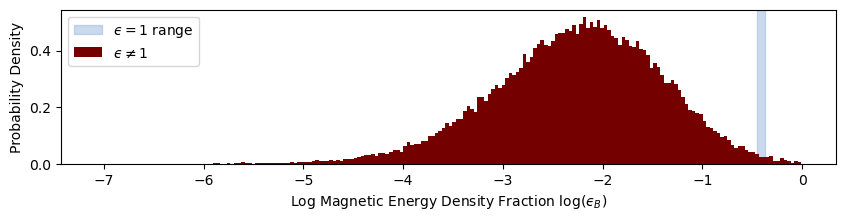

In [28]:
epsB = np.array(epsB)
print("length: ", len(epsB))
plt.figure(figsize = (10, 2))
plt.xlabel(r"Log Magnetic Energy Density Fraction $\log(ϵ_B)$")
plt.ylabel(r"Probability Density")
equip_eB = lambda p : 2*(p+1)/(2*p+13)
plt.axvspan(np.log10(equip_eB(2)), np.log10(equip_eB(3)), linestyle = "-", color = "#96B4DF", label = r"$ϵ=1$ range", alpha = 0.5)
values, bins, patches = plt.hist(np.log10(epsB), bins = 200, density = True, label = r"$ϵ\neq1$", color = "#750000")
plt.legend()
print("epsB", np.mean(epsB), "±", np.std(epsB, ddof = 1))
print("50\% CI", *confidence_interval(epsB)[1:])
plt.savefig("magenergydensityfractionAGN.svg")

In [29]:
len(epsB[(equip_eB(2) < epsB)  & (epsB < equip_eB(3))])/len(epsB)

0.001661362317100022

In [30]:
import random

epsB = np.array([random.choice(epsB) for i in range(0, N)])
epsB

array([0.00127761, 0.29525838, 0.00299395, ..., 0.01291696, 0.01746994,
       0.00035285], shape=(5000000,))

In [31]:
eq = Equipartition(Fmjy, nup10, 1e12, z, 0, p = p, newtonian = True,\
              hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True, BDfactor = False,\
              epse = epse, epsB = epsB, fA = 1, fV = 0.36, fOmega = 4, cosmo = COSMO)

In [32]:
print("Keim et al. 2019 J0231−0433 equipartition analysis with corrections (out of equipartition)")
E = eq.energyeq()
print("          equipartition E = {:.3e}±{:.3e}".format(np.mean(E), np.std(E)))
_, lb, ub = confidence_interval(E)
print("confidence interval         [{:.3e}, {:.3e}]".format(lb, ub))
print("confidence                ", len(E[(lb < E) & (E < ub)])/len(E))
print("          equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("          equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
numDens = eq.CNMnumDens()
print("          equipartition n = {:.3e}±{:.3e}".format(np.mean(numDens), np.std(numDens)))
_, lb, ub = confidence_interval(numDens)
print("confidence interval         [{:.3e}, {:.3e}]".format(lb, ub))
print("confidence                ", len(numDens[(lb < numDens) & (numDens < ub)])/len(numDens))
Ne = eq.Ne()
print("          equipartition Ne= {:.3e}±{:.3e}".format(np.mean(Ne), np.std(Ne)))
_, lb, ub = confidence_interval(Ne)
print("confidence interval         [{:.3e}, {:.3e}]".format(lb, ub))
print("confidence                ", len(Ne[(lb < Ne) & (Ne < ub)])/len(Ne))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("          equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))
print("          equipartition ge= {:.3e}±{:.3e}".format(np.mean(eq.gammae()), np.std(eq.gammae())))
print("         equipartition nua= {:.3e}±{:.3e}".format(np.mean(eq.nusyn(eq.gammae())), np.std(eq.nusyn(eq.gammae()))))
print("                       nuc= {:.3e}±{:.3e}".format(np.mean(eq.nuc()), np.std(eq.nuc())))
print("                     curlc= {:.3e}±{:.3e}".format(np.mean(eq.C()), np.std(eq.C())))

Keim et al. 2019 J0231−0433 equipartition analysis with corrections (out of equipartition)
          equipartition E = 3.562e+54±6.241e+54
confidence interval         [1.299e+54, 5.825e+54]
confidence                 0.4999996
          equipartition R = 2.822e+19±6.335e+18
          equipartition B = 3.857e-03±1.862e-03
          equipartition n = 2.877e+00±7.350e+00
confidence interval         [8.966e-01, 4.857e+00]
confidence                 0.5000046
          equipartition Ne= 2.138e+59±3.740e+59
confidence interval         [7.809e+58, 3.496e+59]
confidence                 0.5
newtonian          betaeqN= 1.294e-08±2.906e-09
          equipartition gM= 2.000e+00±0.000e+00
          equipartition ge= 1.860e+02±4.573e+01
         equipartition nua= 2.677e+08±3.542e+07
                       nuc= 2.279e-02±1.386e-01
                     curlc= 3.736e+00±4.461e-01


min gammae is 1.196305260421e+02 and max is 1.655183328216e+02


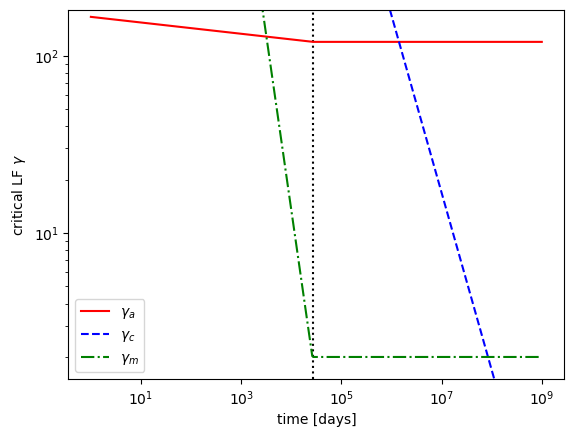

In [33]:
t = np.geomspace(1, 1000000000, 500)
eq = Equipartition(Fmjy_scalar, nup10_scalar, t, z, 0, p = p_scalar, newtonian = True,\
              hotprotons = True, numelectrons = True, outofequipartition = False, energysum = True, BDfactor = False,\
              epse = epse, fA = 1, fV = 0.36, fOmega = 4, cosmo = COSMO)

plt.axvline(t[np.where(eq.gammaM() == 2)[0][0]], color = "k", linestyle = ":")
plt.ylim(1.5, 1.1 * np.max(eq.gammae())) 
plt.ylabel(r"critical LF $\gamma$")
plt.xlabel("time [days]")
plt.loglog(t, eq.gammae(), color = "r", linestyle = "-", label = r"$\gamma_a$")
print("min gammae is {:.12e} and max is {:.12e}".format(np.min(eq.gammae()), np.max(eq.gammae())))
plt.loglog(t, eq.gammac(), color = "b", linestyle = "--", label = r"$\gamma_c$")
plt.loglog(t, eq.gammaM(), color = "g", linestyle = "-.", label = r"$\gamma_m$")
plt.legend()

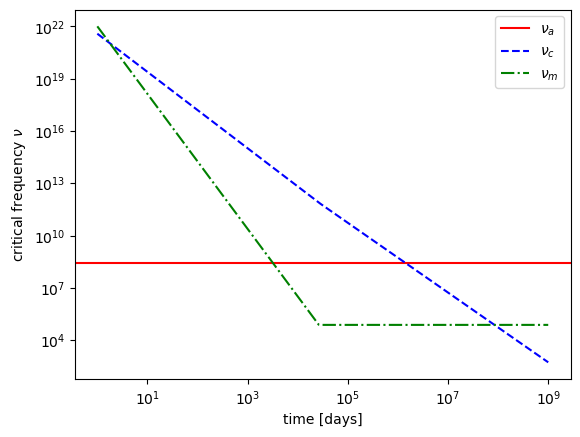

In [34]:
plt.ylabel(r"critical frequency $\nu$")
plt.xlabel("time [days]")
plt.axhline(eq.nup, color = "r", linestyle = "-", label = r"$\nu_a$")
plt.loglog(t, eq.nuc(), color = "b", linestyle = "--", label = r"$\nu_c$")
plt.loglog(t, eq.nusyn(eq.gammaM()), color = "g", linestyle = "-.", label = r"$\nu_m$")
plt.legend()